In [5]:
import pandas as pd
df=pd.read_csv("heartdisease.csv")
print(df.head())
print(df["target"].value_counts())

   age  sex  cp  trestbps  chol  fbs  thalach  exang  oldpeak  ca  target
0   49    0   3       177   150    0       95      0      2.3   0       0
1   56    1   0       124   172    1       86      1      0.5   0       1
2   66    0   3       100   239    0      105      0      1.7   0       0
3   64    0   0       168   222    0       95      1      2.8   0       1
4   60    1   2       153   358    0      147      0      3.2   0       1
1    11
0     5
Name: target, dtype: int64


In [16]:
x=df.drop("target",axis=1)
y=df["target"]
from sklearn.model_selection import train_test_split
X_train,x_test,y_train,y_test=train_test_split(
x,y,test_size=0.2,random_state=42
)

In [18]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression(max_iter=1000)
model.fit(x_train,y_train)
pred=model.predict(x_test)
print(pred[:10])

[1 0 1 1]


In [19]:
from sklearn.metrics import(
accuracy_score,confusion_matrix,
precision_score,recall_score,f1_score
)
acc=accuracy_score(y_test,pred)
cm=confusion_matrix(y_test,pred)
prec=precision_score(y_test,pred)
rec=recall_score(y_test,pred)
f1=f1_score(y_test,pred)
print(acc,prec,rec,f1)
print(cm)

0.25 0.3333333333333333 0.5 0.4
[[0 2]
 [1 1]]


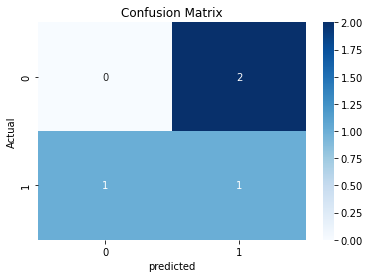

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues")
plt.xlabel("predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [21]:
from sklearn.neighbors import KNeighborsClassifier
Knn=KNeighborsClassifier(n_neighbors=5)
Knn.fit(x_train,y_train)
pred_Knn=Knn.predict(x_test)
print(accuracy_score(y_test,pred_Knn))

0.5


In [24]:
for K in [1,3,5,7,9]:
    Knn=KNeighborsClassifier(n_neighbors=K)
    Knn.fit(x_train,y_train)
    pred_K=Knn.predict(x_test)
    acc_K=accuracy_score(y_test,pred_K)
    print("K=",K,"->Accuracy:",acc_K)

K= 1 ->Accuracy: 0.25
K= 3 ->Accuracy: 0.25
K= 5 ->Accuracy: 0.5
K= 7 ->Accuracy: 0.5
K= 9 ->Accuracy: 0.5
